# Introduction to Data Science with Python

Based on *Lab_Intro_to_data.pdf*. This lab explores data types, calculates descriptive statistics and draws a histogram using the worksheet's example data.

Run the cells in order using **Python (University)**. The required libraries are NumPy, pandas, Matplotlib and SciPy. They are installed in this environment. In another environment, run `%pip install numpy pandas matplotlib scipy` in a separate cell if needed.

## Step 1 - Import the Libraries

In [1]:
# NumPy provides numerical calculations; pandas organizes tabular data.
import numpy as np
import pandas as pd

# Matplotlib draws the histogram; SciPy calculates the mode.
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 - Explore Data Types

| Example | Type | Meaning |
| --- | --- | --- |
| Heights | Continuous numerical | A measurement that can include fractional values, even when recorded as whole numbers. |
| Purchases | Discrete numerical | A count of purchases, recorded in whole numbers. |
| Gender and State | Nominal categorical | Labels without an inherent ranking. |
| Movie Rating | Ordinal categorical | Ordered categories from 1 to 5; equal gaps between ratings are not guaranteed. |

A variable's meaning determines its statistical type. An integer column can represent a count, a rounded measurement, or an ordered rating.

In [2]:
# Keep the same example values as the worksheet.
numerical_data = {
    "Heights": [165, 170, 168, 172, 177],
    "Purchases": [2, 3, 1, 5, 4]
}

categorical_data = {
    "Gender": ["Male", "Female", "Female", "Male", "Male"],
    "State": ["TX", "CA", "NY", "CA", "TX"]
}

ordinal_data = {
    "Movie Rating": [5, 3, 4, 2, 1]
}

print("Numerical Data:", numerical_data)
print("Categorical Data:", categorical_data)
print("Ordinal Data:", ordinal_data)

Numerical Data: {'Heights': [165, 170, 168, 172, 177], 'Purchases': [2, 3, 1, 5, 4]}
Categorical Data: {'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'], 'State': ['TX', 'CA', 'NY', 'CA', 'TX']}
Ordinal Data: {'Movie Rating': [5, 3, 4, 2, 1]}


In [3]:
# Display the five worksheet examples together in a table.
examples = pd.DataFrame({**numerical_data, **categorical_data, **ordinal_data})

# Explicitly represent nominal labels as categorical columns.
examples["Gender"] = examples["Gender"].astype("category")
examples["State"] = examples["State"].astype("category")

# Represent ratings as ordered categories rather than ordinary measurements.
rating_type = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True)
examples["Movie Rating"] = examples["Movie Rating"].astype(rating_type)

display(examples)
print("\nPandas storage types:")
print(examples.dtypes)
print("\nMovie ratings are ordered:", examples["Movie Rating"].cat.ordered)

,Heights,Purchases,Gender,State,Movie Rating
0,165,2,Male,TX,5
1,170,3,Female,CA,3
2,168,1,Female,NY,4
3,172,5,Male,CA,2
4,177,4,Male,TX,1



Pandas storage types:
Heights            int64
Purchases          int64
Gender          category
State           category
Movie Rating    category
dtype: object

Movie ratings are ordered: True


## Step 3 - Create the Statistics Dataset

The worksheet uses nine observations: `[0, 2, 3, 2, 1, 0, 0, 2, 0]`. Sorting them helps identify the middle value; counting them helps identify the most frequent value.

In [4]:
# This is a separate dataset from the data-type examples above.
data = np.array([0, 2, 3, 2, 1, 0, 0, 2, 0])

print("Dataset:", data.tolist())
print("Sorted dataset:", np.sort(data).tolist())
print("Number of observations:", data.size)
print("Sum of observations:", data.sum())

# Count how often each value appears.
frequency_table = pd.Series(data, name="Value").value_counts().sort_index()
frequency_table.index.name = "Value"
frequency_table.name = "Frequency"
display(frequency_table.to_frame())

Dataset: [0, 2, 3, 2, 1, 0, 0, 2, 0]
Sorted dataset: [0, 0, 0, 0, 1, 2, 2, 2, 3]
Number of observations: 9
Sum of observations: 10


,Frequency
Value,
0,4
1,1
2,3
3,1


## Step 4 - Calculate Mean, Median and Mode

- **Mean:** the sum of the observations divided by their count.
- **Median:** the middle observation after sorting. With nine values, this is the fifth value.
- **Mode:** the most frequent value.

The worksheet uses `mode_value.mode[0]`. Current SciPy can return a scalar when `keepdims=False`, so this notebook explicitly uses that setting and reads `.mode.item()` without indexing. See the [SciPy mode documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mode.html).

In [5]:
# Average: 10 divided by 9 observations.
mean_value = np.mean(data)

# Middle value of the sorted dataset.
median_value = np.median(data)

# SciPy also returns how often the modal value occurs.
mode_result = stats.mode(data, keepdims=False)
mode_value = mode_result.mode.item()
mode_count = mode_result.count.item()

print(f"Mean:   {mean_value:.6f}")
print(f"Median: {median_value:g}")
print(f"Mode:   {mode_value} (occurs {mode_count} times)")

Mean:   1.111111
Median: 1
Mode:   0 (occurs 4 times)


## Step 5 - Calculate Variance and Standard Deviation

**Variance** is the average squared distance from the mean. **Standard deviation** is the square root of variance, expressed in the same units as the original values.

The worksheet's `np.var()` and `np.std()` use population calculations by default, dividing by $N$. We make this explicit with `ddof=0`.

If the observations are treated as a sample used to estimate a larger population's variance, `ddof=1` divides by $N-1$. The sample results below are included for comparison.

In [6]:
# Population statistics, matching the worksheet.
variance_value = np.var(data, ddof=0)
std_dev_value = np.std(data, ddof=0)

# Sample statistics use N - 1 in the denominator.
sample_variance = np.var(data, ddof=1)
sample_std_dev = np.std(data, ddof=1)

print(f"Population variance:           {variance_value:.6f}")
print(f"Population standard deviation: {std_dev_value:.6f}")
print(f"Sample variance:               {sample_variance:.6f}")
print(f"Sample standard deviation:     {sample_std_dev:.6f}")

# Summarize the five statistics requested in the lab.
summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Population variance", "Population standard deviation"],
    "Value": [mean_value, median_value, mode_value, variance_value, std_dev_value]
})
display(summary.round(6))

Population variance:           1.209877
Population standard deviation: 1.099944
Sample variance:               1.361111
Sample standard deviation:     1.166667


,Statistic,Value
0,Mean,1.111111
1,Median,1.000000
2,Mode,0.000000
3,Population variance,1.209877
4,Population standard deviation,1.099944


## Step 6 - Draw the Histogram

A histogram groups numerical values into intervals and shows how many observations fall in each interval. This follows the worksheet's choice of five bins.

The values here are integers from 0 to 3. Five equal-width bins create one empty interval, which is a consequence of the bin choice rather than a missing observation. The frequency table above gives the exact counts for each integer.

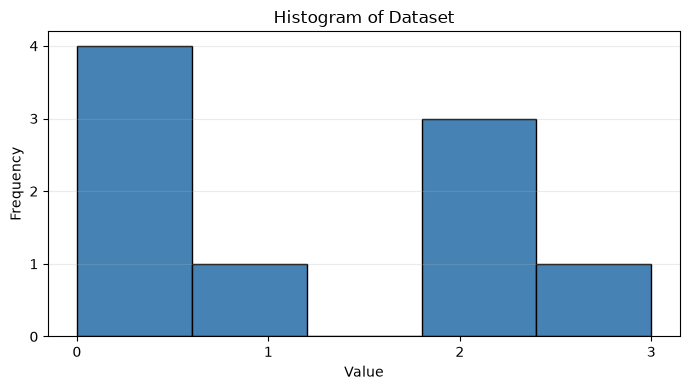

Observations represented in the histogram: 9


In [7]:
# Create the five-bin histogram used in the worksheet.
fig, ax = plt.subplots(figsize=(7, 4))
counts, bin_edges, patches = ax.hist(data, bins=5, edgecolor="black", color="steelblue")

ax.set_title("Histogram of Dataset")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_xticks([0, 1, 2, 3])
ax.set_yticks(range(0, 5))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

# Save a reusable copy as well as displaying the plot in the notebook.
fig.savefig("histogram.png", dpi=160)
plt.show()
plt.close(fig)

print("Observations represented in the histogram:", int(counts.sum()))

## Findings

- The dataset contains **9 observations** and sums to **10**.
- The mean is approximately **1.111111**, while the median is **1**.
- The mode is **0**, occurring **4 times**. Values 1, 2 and 3 occur 1, 3 and 1 times respectively.
- The population variance is approximately **1.209877** and the population standard deviation is **1.099944**.
- The histogram shows that 0 is the most frequent value, followed by 2.
- Numerical storage does not always mean a variable is a measurement: movie ratings are ordered categories.

These statistics describe only the supplied example dataset. No predictive model is trained in this lab.